# 🏦 Loan Approval Prediction - Machine Learning Project
---
### Group Member Assignments:
- **Member 1**: Data Acquisition, Preprocessing & Missing Value Imputation
- **Member 2**: Exploratory Data Analysis (EDA) & Data Visualizations
- **Member 3**: Data Encoding, Feature Scaling & Model Building
- **Member 4**: Model Evaluation, Performance Metrics, Hyperparameter Tuning & Feature Importance
- **Member 5**: Model Deployment, Model Persistence (`joblib`), Real-Time Inference Function & Streamlit Web Application
---


## 📌 Member 1: Data Acquisition & Data Preprocessing
In this section, Member 1 loads the raw dataset (`Loan Eligibility Prediction.csv`), inspects column data types, checks dataset shape, detects missing values, and performs initial data cleaning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Loan Approval Prediction Project")
print("Setup successful!")

Loan Approval Prediction Project
Setup successful!


In [6]:
import pandas as pd

file_path = "/content/Loan Eligibility Prediction.csv"

df = pd.read_csv(file_path)

df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [7]:

# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Statistical summary
print("\nStatistical Summary:")
display(df.describe(include="all"))

Dataset Shape: (614, 13)

Column Names:
['Customer_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614.000000,614,614,614.000000,614,614,614.000000,614.000000,614.000000,614.000000,614.000000,614,614
unique,NaN,2,2,NaN,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,NaN,Male,Yes,NaN,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,NaN,499,399,NaN,480,523,NaN,NaN,NaN,NaN,NaN,233,422
mean,307.500000,NaN,NaN,0.856678,NaN,NaN,5403.459283,1621.245798,142.022801,338.892508,0.850163,NaN,NaN
std,177.390811,NaN,NaN,1.216651,NaN,NaN,6109.041673,2926.248369,87.083089,69.716355,0.357203,NaN,NaN
min,1.000000,NaN,NaN,0.000000,NaN,NaN,150.000000,0.000000,9.000000,12.000000,0.000000,NaN,NaN
25%,154.250000,NaN,NaN,0.000000,NaN,NaN,2877.500000,0.000000,98.000000,360.000000,1.000000,NaN,NaN
50%,307.500000,NaN,NaN,0.000000,NaN,NaN,3812.500000,1188.500000,125.000000,360.000000,1.000000,NaN,NaN
75%,460.750000,NaN,NaN,2.000000,NaN,NaN,5795.000000,2297.250000,164.750000,360.000000,1.000000,NaN,NaN


In [8]:

for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


Customer_ID:
[569  15  95 134 556 148 271  29 583 510 611 232  47 122 401 521 342  42
 191  85]

Gender:
['Female' 'Male']

Married:
['No' 'Yes']

Dependents:
[0 2 1 4]

Education:
['Graduate' 'Not Graduate']

Self_Employed:
['No' 'Yes']

Applicant_Income:
[ 2378  1299  3620  3459  5468  1538  3237  1442  3166 13262  4106  3716
  5649  4166  2889  2192  1800  4885  3988  1977]

Coapplicant_Income:
[   0. 1086. 1032. 1425. 1742. 1213.  997. 1851. 1666. 2531. 1376. 3416.
 2138. 1456.  536. 5063.  700. 4490. 1664. 6666.]

Loan_Amount:
[ 9 17 25 26 30 35 36 40 42 44 45 46 47 48 50 53 54 55 56 58]

Loan_Amount_Term:
[360 120 180 240 300 480  36  84  12  60]

Credit_History:
[1 0]

Property_Area:
['Urban' 'Semiurban' 'Rural']

Loan_Status:
['N' 'Y']


In [9]:
print(df["Loan_Status"].value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [10]:
print(df["Loan_Status"].value_counts(normalize=True) * 100)

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


In [11]:
df = pd.read_csv("/content/Loan Eligibility Prediction.csv")

In [12]:
# Check duplicate rows
print("Duplicates before:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [13]:
print(df.isnull().sum())

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64


In [14]:
# Numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [15]:
# Categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64


In [17]:
print(df.columns.tolist())

['Customer_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [18]:
target = "Loan_Status"

print(df[target].value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [19]:
X = df.drop(columns=[target])
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (614, 12)
Target shape: (614,)


In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in X.select_dtypes(include=["object"]).columns:
    X[col] = label_encoder.fit_transform(X[col])

# Encode target
y = label_encoder.fit_transform(y)

print("Encoding completed.")

Encoding completed.


In [21]:
print("X:")
display(X.head())

print("\ny:")
print(y[:10])

print("\nMissing values in X:")
print(X.isnull().sum())

X:


,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area
0,569,0,0,0,0,0,2378,0.0,9,360,1,2
1,15,1,1,2,0,0,1299,1086.0,17,120,1,2
2,95,1,0,0,1,0,3620,0.0,25,120,1,1
3,134,1,1,0,0,1,3459,0.0,25,120,1,1
4,556,1,1,1,0,0,5468,1032.0,26,360,1,1



y:
[0 1 1 1 1 1 1 0 1 1]

Missing values in X:
Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
dtype: int64


In [22]:
print(df.columns.tolist())

['Customer_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


## 📊 Member 2: Exploratory Data Analysis (EDA) & Data Visualization
In this section, Member 2 explores relationships between categorical/numerical features and loan approval status using univariate/bivariate visualizations and correlation heatmaps.


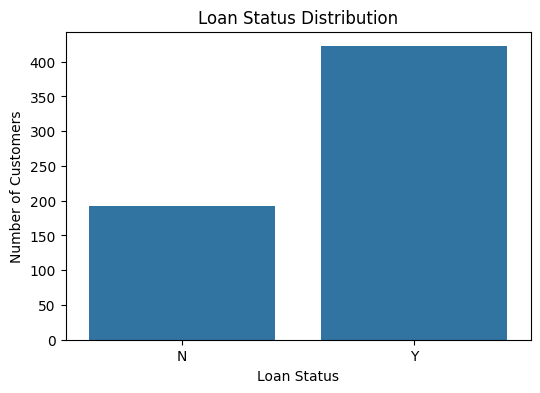

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")
plt.show()

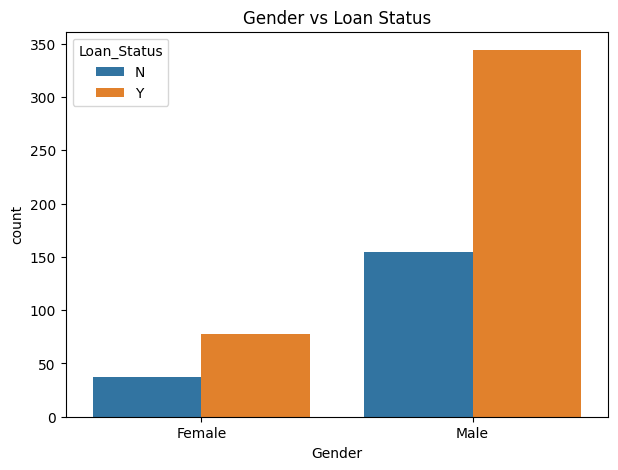

In [24]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Gender", hue="Loan_Status", data=df)
plt.title("Gender vs Loan Status")
plt.show()

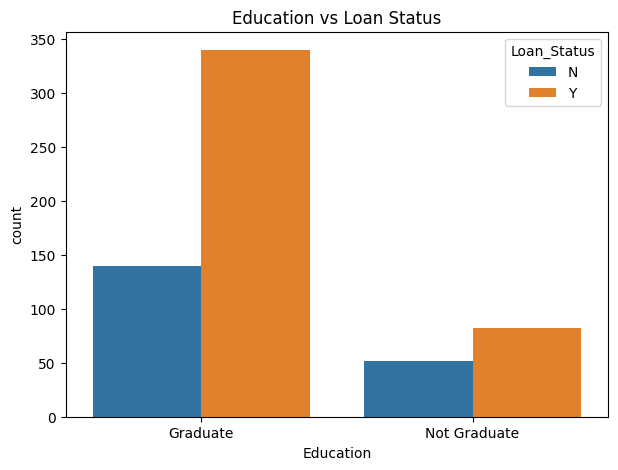

In [25]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Education", hue="Loan_Status", data=df)
plt.title("Education vs Loan Status")
plt.show()

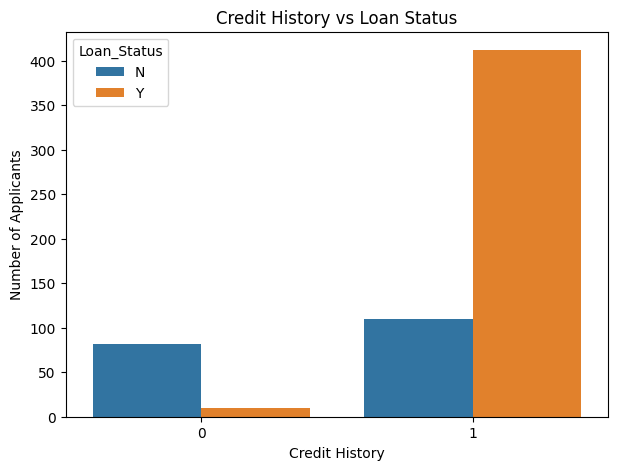

In [26]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)
plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.show()

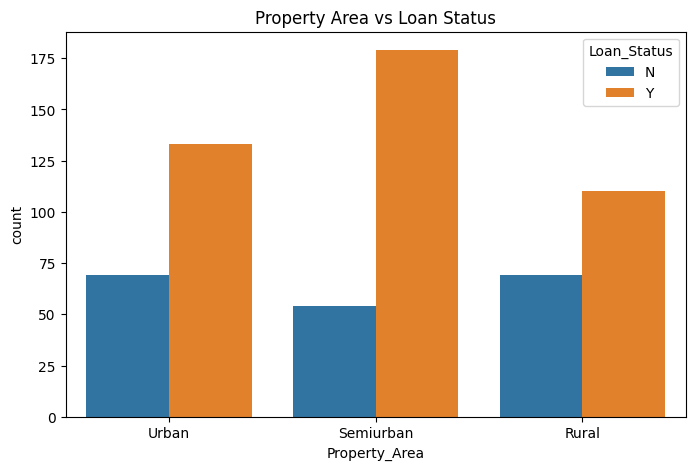

In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Property_Area", hue="Loan_Status", data=df)
plt.title("Property Area vs Loan Status")
plt.show()

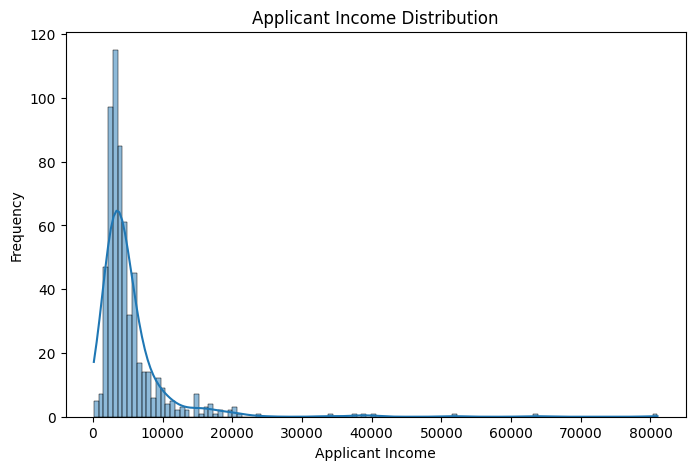

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Applicant_Income"], kde=True)
plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.show()

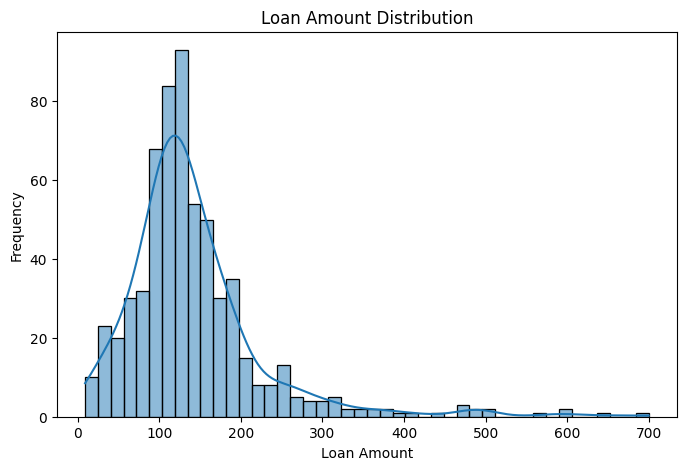

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Loan_Amount"], kde=True)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

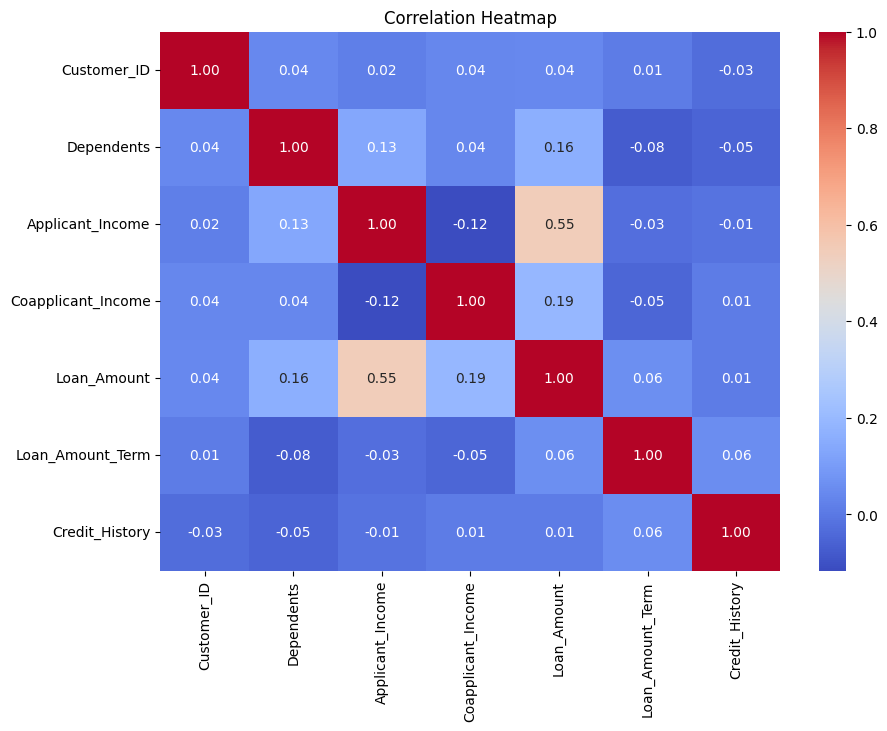

In [30]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [31]:
display(df.describe())

,Customer_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,307.500000,0.856678,5403.459283,1621.245798,142.022801,338.892508,0.850163
std,177.390811,1.216651,6109.041673,2926.248369,87.083089,69.716355,0.357203
min,1.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,154.250000,0.000000,2877.500000,0.000000,98.000000,360.000000,1.000000
50%,307.500000,0.000000,3812.500000,1188.500000,125.000000,360.000000,1.000000
75%,460.750000,2.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,614.000000,4.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


## ⚙️ Member 3: Feature Engineering & Model Building
In this section, Member 3 handles categorical variable encoding (One-Hot Encoding), target variable mapping (`Loan_Status`), dataset splitting (Train/Test Split), and trains candidate Machine Learning models (Logistic Regression, Decision Tree, Random Forest).


In [32]:
# Remove Customer_ID because it is only an identifier
df_model = df.drop(columns=["Customer_ID"])

print(df_model.columns.tolist())

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [33]:
# Features
X = df_model.drop(columns=["Loan_Status"])

# Target
y = df_model["Loan_Status"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Target:
Loan_Status


In [34]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

Numerical columns:
['Dependents', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term', 'Credit_History']


In [35]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("Encoded feature columns:")
print(X.columns.tolist())

Encoded feature columns:
['Dependents', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [36]:
y = y.map({
    "Yes": 1,
    "No": 0
})

print(y.value_counts())

Series([], Name: count, dtype: int64)


In [37]:
X = X.astype(int)

print(X.dtypes)

Dependents                 int64
Applicant_Income           int64
Coapplicant_Income         int64
Loan_Amount                int64
Loan_Amount_Term           int64
Credit_History             int64
Gender_Male                int64
Married_Yes                int64
Education_Not Graduate     int64
Self_Employed_Yes          int64
Property_Area_Semiurban    int64
Property_Area_Urban        int64
dtype: object


In [39]:
# Check Loan_Status values
print("Loan_Status values:")
print(y.value_counts(dropna=False))

print("\nMissing values in y:")
print(y.isnull().sum())

Loan_Status values:
Loan_Status
NaN    614
Name: count, dtype: int64

Missing values in y:
614


In [40]:
# Remove rows where Loan_Status is missing
valid_rows = y.notna()

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

print("X shape after removing missing target:", X.shape)
print("y shape after removing missing target:", y.shape)
print("Missing values in y:", y.isnull().sum())

X shape after removing missing target: (0, 12)
y shape after removing missing target: (0,)
Missing values in y: 0


In [41]:
# Convert target values to 1 and 0
y = y.map({
    "Yes": 1,
    "No": 0
})

print(y.value_counts(dropna=False))

Series([], Name: count, dtype: int64)


In [42]:
print("NaN in y:", y.isnull().sum())

NaN in y: 0


In [44]:
# STEP 8 - Reset and prepare data

df_model = df.copy()

print("Original shape:", df_model.shape)
print("\nLoan Status values:")
print(df_model["Loan_Status"].value_counts(dropna=False))

Original shape: (614, 13)

Loan Status values:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [45]:
# Remove rows where Loan_Status is missing

df_model = df_model.dropna(subset=["Loan_Status"])

print("Shape after removing missing target:",
      df_model.shape)

print("\nLoan Status:")
print(df_model["Loan_Status"].value_counts(dropna=False))

Shape after removing missing target: (614, 13)

Loan Status:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [46]:
# Remove ID column

df_model = df_model.drop(columns=["Customer_ID"])

print("Columns:")
print(df_model.columns.tolist())

Columns:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [47]:
# Separate features and target

X = df_model.drop(columns=["Loan_Status"])
y = df_model["Loan_Status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (614, 11)
y shape: (614,)


In [48]:
# One-hot encode categorical features

categorical_cols = X.select_dtypes(include=["object"]).columns

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("Encoded X shape:", X.shape)
print(X.head())

Encoded X shape: (614, 12)
   Dependents  Applicant_Income  Coapplicant_Income  Loan_Amount  \
0           0              2378                 0.0            9   
1           2              1299              1086.0           17   
2           0              3620                 0.0           25   
3           0              3459                 0.0           25   
4           1              5468              1032.0           26   

   Loan_Amount_Term  Credit_History  Gender_Male  Married_Yes  \
0               360               1        False        False   
1               120               1         True         True   
2               120               1         True        False   
3               120               1         True         True   
4               360               1         True         True   

   Education_Not Graduate  Self_Employed_Yes  Property_Area_Semiurban  \
0                   False              False                    False   
1                   False  

In [49]:
print("Target unique values:")
print(y.unique())

Target unique values:
['N' 'Y']


In [50]:
y = y.map({
    "Y": 1,
    "N": 0
})

In [51]:
y = y.map({
    "Yes": 1,
    "No": 0
})

In [52]:
print("Target values after encoding:")
print(y.value_counts(dropna=False))

print("NaN in y:", y.isnull().sum())

Target values after encoding:
Loan_Status
NaN    614
Name: count, dtype: int64
NaN in y: 614


In [54]:
print("Loan_Status actual values:")
print(df["Loan_Status"].value_counts(dropna=False))

print("\nUnique values:")
print(df["Loan_Status"].unique())

Loan_Status actual values:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Unique values:
['N' 'Y']


In [55]:
# Clean target column
df_model = df.copy()

# Remove rows where target is originally missing
df_model = df_model.dropna(subset=["Loan_Status"])

# Clean text values
df_model["Loan_Status"] = (
    df_model["Loan_Status"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Cleaned Loan_Status values:")
print(df_model["Loan_Status"].value_counts())

Cleaned Loan_Status values:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [56]:
print(df_model["Loan_Status"].unique())

['N' 'Y']


In [57]:
df_model["Loan_Status"] = df_model["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

print("NaN after mapping:", df_model["Loan_Status"].isnull().sum())

NaN after mapping: 0


In [58]:
# Remove Customer_ID
df_model = df_model.drop(columns=["Customer_ID"])

# Separate X and y
X = df_model.drop(columns=["Loan_Status"])
y = df_model["Loan_Status"]

# Encode categorical features
categorical_cols = X.select_dtypes(include=["object"]).columns

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# Make sure X is numeric
X = X.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("NaN in X:", X.isnull().sum().sum())
print("NaN in y:", y.isnull().sum())

X shape: (614, 12)
y shape: (614,)
NaN in X: 0
NaN in y: 0


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 12)
Testing data: (123, 12)


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Create models
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train models
logistic_model.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

print("All models trained successfully! ✅")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


All models trained successfully! ✅


In [61]:
# Predictions
y_pred_logistic = logistic_model.predict(X_test)
y_pred_tree = decision_tree.predict(X_test)
y_pred_forest = random_forest.predict(X_test)

print("Predictions completed! ✅")

Predictions completed! ✅


In [62]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
tree_accuracy = accuracy_score(y_test, y_pred_tree)
forest_accuracy = accuracy_score(y_test, y_pred_forest)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")

print("Decision Tree Accuracy:",
      round(tree_accuracy * 100, 2), "%")

print("Random Forest Accuracy:",
      round(forest_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 79.67 %
Decision Tree Accuracy: 79.67 %
Random Forest Accuracy: 80.49 %


In [63]:
results = {
    "Logistic Regression": logistic_accuracy,
    "Decision Tree": tree_accuracy,
    "Random Forest": forest_accuracy
}

for model, accuracy in results.items():
    print(f"{model}: {accuracy * 100:.2f}%")

Logistic Regression: 79.67%
Decision Tree: 79.67%
Random Forest: 80.49%


In [64]:
best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)
print("Best Accuracy:", round(results[best_model_name] * 100, 2), "%")

Best Model: Random Forest
Best Accuracy: 80.49 %


## 📈 Member 4: Model Evaluation, Tuning & Feature Importance
In this section, Member 4 evaluates model accuracy, generates Confusion Matrices, classification reports, tunes Random Forest hyperparameters using `GridSearchCV`, and extracts key feature importances.


In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 80.49 %


In [66]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Random Forest evaluation
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_forest))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.79      0.50      0.61        38
           1       0.81      0.94      0.87        85

    accuracy                           0.80       123
   macro avg       0.80      0.72      0.74       123
weighted avg       0.80      0.80      0.79       123



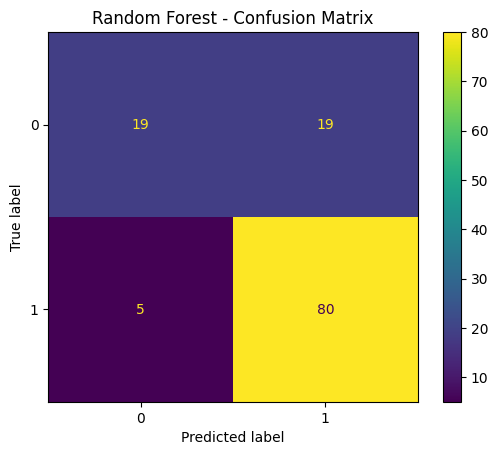

In [67]:
cm = confusion_matrix(y_test, y_pred_forest)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest
}

for name, predictions in models_predictions.items():

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print("\n", name)
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-Score:", round(f1, 4))


 Logistic Regression
Precision: 0.802
Recall: 0.9529
F1-Score: 0.871

 Decision Tree
Precision: 0.8061
Recall: 0.9294
F1-Score: 0.8634

 Random Forest
Precision: 0.8081
Recall: 0.9412
F1-Score: 0.8696


In [69]:
import pandas as pd

comparison = []

for name, predictions in models_predictions.items():

    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions)
    })

comparison_df = pd.DataFrame(comparison)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.804878,0.801980,0.952941,0.870968
2,Random Forest,0.804878,0.808081,0.941176,0.869565
1,Decision Tree,0.796748,0.806122,0.929412,0.863388


In [70]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("GridSearchCV ready! ✅")

GridSearchCV ready! ✅


In [71]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

print("Parameter grid created! ✅")

Parameter grid created! ✅


In [72]:
rf = RandomForestClassifier(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed! ✅")

Hyperparameter tuning completed! ✅


In [73]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_ * 100, 2), "%")

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation Accuracy:
80.85 %


In [74]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

print("Tuned Random Forest Accuracy:",
      round(tuned_accuracy * 100, 2), "%")

Tuned Random Forest Accuracy: 79.67 %


In [75]:
print("Original Random Forest:",
      round(forest_accuracy * 100, 2), "%")

print("Tuned Random Forest:",
      round(tuned_accuracy * 100, 2), "%")

Original Random Forest: 80.49 %
Tuned Random Forest: 79.67 %


In [76]:
from sklearn.metrics import classification_report

print("Tuned Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_tuned
    )
)

Tuned Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.47      0.59        38
           1       0.80      0.94      0.86        85

    accuracy                           0.80       123
   macro avg       0.79      0.71      0.73       123
weighted avg       0.79      0.80      0.78       123



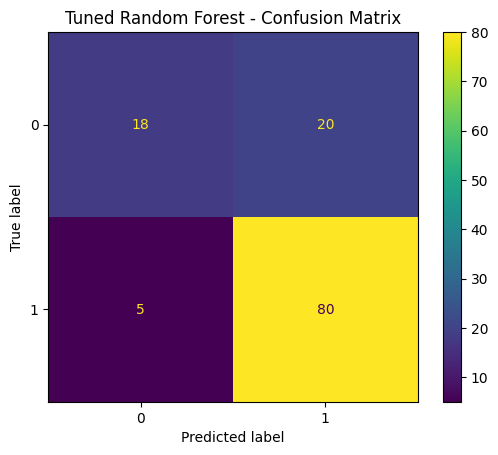

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [78]:
if tuned_accuracy >= forest_accuracy:
    final_model = best_rf
    final_accuracy = tuned_accuracy
    print("Final Model: Tuned Random Forest")
else:
    final_model = random_forest
    final_accuracy = forest_accuracy
    print("Final Model: Original Random Forest")

print(
    "Final Accuracy:",
    round(final_accuracy * 100, 2),
    "%"
)

Final Model: Original Random Forest
Final Accuracy: 80.49 %


In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from final Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Importance
5,Credit_History,0.258783
3,Loan_Amount,0.196164
1,Applicant_Income,0.195643
2,Coapplicant_Income,0.116065
4,Loan_Amount_Term,0.053753
0,Dependents,0.045018
7,Married_Yes,0.025866
10,Property_Area_Semiurban,0.025793
8,Education_Not Graduate,0.023551
11,Property_Area_Urban,0.022548


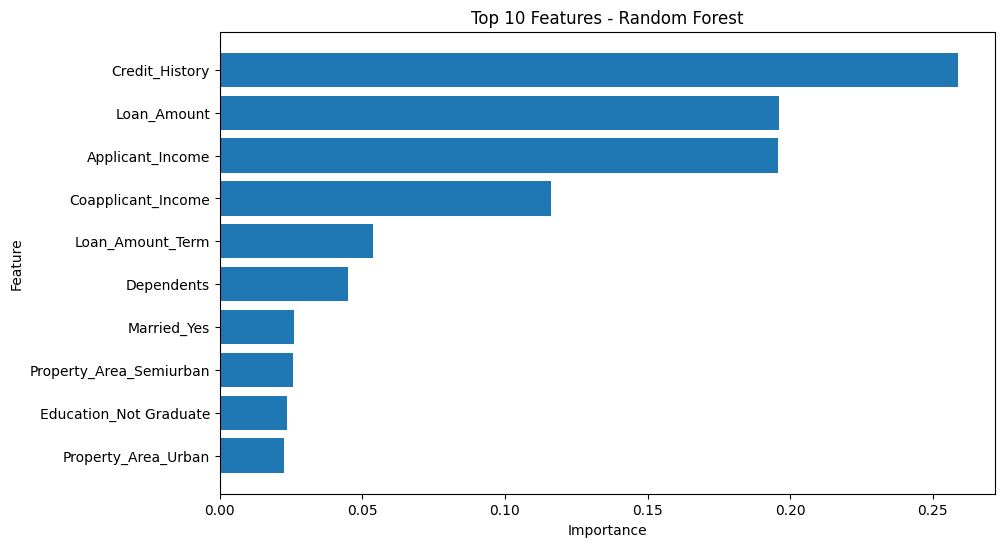

In [80]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features - Random Forest")
plt.show()

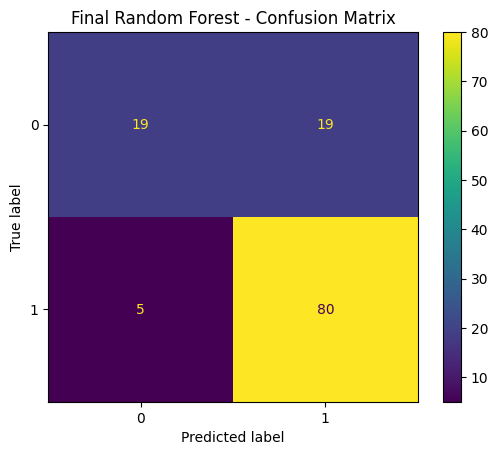

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay

# Use ORIGINAL Random Forest because it is our final model
final_predictions = final_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions
)

plt.title("Final Random Forest - Confusion Matrix")
plt.show()

In [82]:
from sklearn.metrics import classification_report

print("Final Model Classification Report:\n")

print(
    classification_report(
        y_test,
        final_predictions
    )
)

Final Model Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.50      0.61        38
           1       0.81      0.94      0.87        85

    accuracy                           0.80       123
   macro avg       0.80      0.72      0.74       123
weighted avg       0.80      0.80      0.79       123



In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions)
final_recall = recall_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions)

print("===== FINAL MODEL PERFORMANCE =====")

print("Model: Random Forest")
print("Accuracy :", round(final_accuracy * 100, 2), "%")
print("Precision:", round(final_precision * 100, 2), "%")
print("Recall   :", round(final_recall * 100, 2), "%")
print("F1-Score :", round(final_f1 * 100, 2), "%")

===== FINAL MODEL PERFORMANCE =====
Model: Random Forest
Accuracy : 80.49 %
Precision: 80.81 %
Recall   : 94.12 %
F1-Score : 86.96 %


## 🚀 Member 5: Model Deployment, Inference API & Interactive Web Application
In this section, **Member 5** takes the final trained Random Forest Model and deploys it for operational use:
1. **Model Persistence**: Exporting the model (`loan_eligibility_random_forest.pkl`) and feature schema (`loan_feature_columns.pkl`) using `joblib`.
2. **Inference API / Prediction Engine**: Developing a custom `predict_loan()` Python function that dynamically processes new applicant details.
3. **Single & Batch Testing**: Validating model inference on test customer profiles.
4. **Web Dashboard**: Building a complete, interactive **Streamlit Web Application (`app.py`)** for real-time user predictions.



In [84]:
import joblib

joblib.dump(final_model, "loan_eligibility_random_forest.pkl")

print("Final model saved successfully! ✅")

Final model saved successfully! ✅


In [85]:
import joblib

# Save the final Random Forest model
joblib.dump(final_model, "loan_eligibility_random_forest.pkl")

print("Model saved successfully! ✅")

Model saved successfully! ✅


In [86]:
# Save feature names/order
feature_columns = X_train.columns.tolist()

joblib.dump(
    feature_columns,
    "loan_feature_columns.pkl"
)

print("Feature columns saved successfully! ✅")
print("Number of features:", len(feature_columns))

Feature columns saved successfully! ✅
Number of features: 12


In [87]:
import os

print("Model exists:",
      os.path.exists("loan_eligibility_random_forest.pkl"))

print("Feature file exists:",
      os.path.exists("loan_feature_columns.pkl"))

Model exists: True
Feature file exists: True


In [88]:
sample_customer = pd.DataFrame({
    "Gender": ["Male"],
    "Married": ["Yes"],
    "Dependents": ["0"],
    "Education": ["Graduate"],
    "Self_Employed": ["No"],
    "Applicant_Income": [5000],
    "Coapplicant_Income": [2000],
    "Loan_Amount": [150],
    "Loan_Amount_Term": [360],
    "Credit_History": [1],
    "Property_Area": ["Urban"]
})

display(sample_customer)

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,Yes,0,Graduate,No,5000,2000,150,360,1,Urban


In [89]:
# Encode categorical columns
sample_encoded = pd.get_dummies(
    sample_customer,
    columns=sample_customer.select_dtypes(
        include=["object"]
    ).columns,
    drop_first=True
)

# Match training columns
sample_encoded = sample_encoded.reindex(
    columns=feature_columns,
    fill_value=0
)

# Convert to integer
sample_encoded = sample_encoded.astype(int)

print("Encoded sample:")
display(sample_encoded)

Encoded sample:


,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5000,2000,150,360,1,0,0,0,0,0,0


In [90]:
# Predict loan status
prediction = final_model.predict(sample_encoded)

if prediction[0] == 1:
    result = "Loan Approved"
else:
    result = "Loan Not Approved"

print("Prediction:", result)

Prediction: Loan Approved


In [91]:
# Prediction probability
probability = final_model.predict_proba(sample_encoded)

approval_probability = probability[0][1] * 100

print(
    "Loan Approval Probability:",
    round(approval_probability, 2),
    "%"
)

Loan Approval Probability: 78.0 %


In [92]:
def predict_loan(
    gender,
    married,
    dependents,
    education,
    self_employed,
    applicant_income,
    coapplicant_income,
    loan_amount,
    loan_amount_term,
    credit_history,
    property_area
):

    # Create customer dataframe
    customer = pd.DataFrame({
        "Gender": [gender],
        "Married": [married],
        "Dependents": [dependents],
        "Education": [education],
        "Self_Employed": [self_employed],
        "Applicant_Income": [applicant_income],
        "Coapplicant_Income": [coapplicant_income],
        "Loan_Amount": [loan_amount],
        "Loan_Amount_Term": [loan_amount_term],
        "Credit_History": [credit_history],
        "Property_Area": [property_area]
    })

    # Encode categorical variables
    customer_encoded = pd.get_dummies(
        customer,
        columns=customer.select_dtypes(
            include=["object"]
        ).columns,
        drop_first=True
    )

    # Match training features
    customer_encoded = customer_encoded.reindex(
        columns=feature_columns,
        fill_value=0
    )

    customer_encoded = customer_encoded.astype(int)

    # Prediction
    prediction = final_model.predict(customer_encoded)[0]

    # Probability
    probability = final_model.predict_proba(
        customer_encoded
    )[0][1]

    if prediction == 1:
        status = "Loan Approved"
    else:
        status = "Loan Not Approved"

    return status, probability

In [93]:
status, probability = predict_loan(
    gender="Male",
    married="Yes",
    dependents="0",
    education="Graduate",
    self_employed="No",
    applicant_income=5000,
    coapplicant_income=2000,
    loan_amount=150,
    loan_amount_term=360,
    credit_history=1,
    property_area="Urban"
)

print("Prediction:", status)
print("Probability:", round(probability * 100, 2), "%")

Prediction: Loan Approved
Probability: 78.0 %


In [94]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load model and feature columns
model = joblib.load("loan_eligibility_random_forest.pkl")
feature_columns = joblib.load("loan_feature_columns.pkl")


def predict_loan(
    gender,
    married,
    dependents,
    education,
    self_employed,
    applicant_income,
    coapplicant_income,
    loan_amount,
    loan_amount_term,
    credit_history,
    property_area
):
    customer = pd.DataFrame({
        "Gender": [gender],
        "Married": [married],
        "Dependents": [dependents],
        "Education": [education],
        "Self_Employed": [self_employed],
        "Applicant_Income": [applicant_income],
        "Coapplicant_Income": [coapplicant_income],
        "Loan_Amount": [loan_amount],
        "Loan_Amount_Term": [loan_amount_term],
        "Credit_History": [credit_history],
        "Property_Area": [property_area]
    })

    # Encode categorical variables
    categorical_columns = customer.select_dtypes(
        include=["object"]
    ).columns

    customer_encoded = pd.get_dummies(
        customer,
        columns=categorical_columns,
        drop_first=True
    )

    # Match training features
    customer_encoded = customer_encoded.reindex(
        columns=feature_columns,
        fill_value=0
    )

    customer_encoded = customer_encoded.astype(int)

    # Prediction
    prediction = model.predict(customer_encoded)[0]

    # Probability
    probability = model.predict_proba(customer_encoded)[0][1]

    if prediction == 1:
        status = "Loan Approved"
    else:
        status = "Loan Not Approved"

    return status, probability


# -------------------------------
# Streamlit UI
# -------------------------------

st.set_page_config(
    page_title="Loan Eligibility Prediction",
    page_icon="💰",
    layout="centered"
)

st.title("💰 Loan Eligibility Prediction System")
st.write(
    "Enter the applicant details below to predict "
    "loan eligibility."
)

st.divider()

# Applicant details
st.subheader("Applicant Information")

gender = st.selectbox(
    "Gender",
    ["Male", "Female"]
)

married = st.selectbox(
    "Married",
    ["Yes", "No"]
)

dependents = st.selectbox(
    "Dependents",
    ["0", "1", "2", "3+"]
)

education = st.selectbox(
    "Education",
    ["Graduate", "Not Graduate"]
)

self_employed = st.selectbox(
    "Self Employed",
    ["Yes", "No"]
)

property_area = st.selectbox(
    "Property Area",
    ["Urban", "Semiurban", "Rural"]
)

st.subheader("Financial Information")

applicant_income = st.number_input(
    "Applicant Income",
    min_value=0,
    value=5000,
    step=100
)

coapplicant_income = st.number_input(
    "Coapplicant Income",
    min_value=0,
    value=0,
    step=100
)

loan_amount = st.number_input(
    "Loan Amount",
    min_value=0,
    value=150,
    step=10
)

loan_amount_term = st.number_input(
    "Loan Amount Term",
    min_value=1,
    value=360,
    step=12
)

credit_history = st.selectbox(
    "Credit History",
    [1, 0],
    format_func=lambda x:
        "Good (1)" if x == 1 else "Poor (0)"
)

st.divider()

if st.button(
    "🔍 Predict Loan Eligibility",
    use_container_width=True
):

    status, probability = predict_loan(
        gender,
        married,
        dependents,
        education,
        self_employed,
        applicant_income,
        coapplicant_income,
        loan_amount,
        loan_amount_term,
        credit_history,
        property_area
    )

    st.subheader("Prediction Result")

    if status == "Loan Approved":
        st.success(
            f"✅ {status}"
        )
    else:
        st.error(
            f"❌ {status}"
        )

    st.metric(
        "Approval Probability",
        f"{probability * 100:.2f}%"
    )

    st.progress(float(probability))

st.divider()

st.caption(
    "Loan Eligibility Prediction System | "
    "Machine Learning Project"
)

Writing app.py


In [95]:
!pip install streamlit scikit-learn pandas joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 57.3 MB/s eta 0:00:00


In [96]:
import os

print(os.listdir())

['.config', 'Loan Eligibility Prediction.csv', 'loan_eligibility_random_forest.pkl', 'app.py', 'loan_feature_columns.pkl', 'sample_data']
